In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys
import os
from scipy.stats import skew , kurtosis
import time
import tsplib95
import math

In [2]:
sys.path.append(os.path.abspath("../src"))
from populacao import Populacao
from pygenec.selecao.torneio import Torneio
from pygenec.cruzamento.edge_recombination import Edge_recombination
from pygenec.cruzamento.unponto import UmPonto

from pygenec.mutacao.inversion import Inversion
from pygenec.mutacao.swap import Swap

from pygenec.busca_local.opt_2 import Opt_2

from evolucao import Evolucao
from evolucao_tsp_classico import Evolucao_classica

from funcoes import Criar_Gif, Imagens_para_gif,Ate_convergir, Melhor_rota, Numero_de_geracoes, Arredondar_cima

In [3]:
sys.path.append(os.path.abspath("../data"))
problema = tsplib95.load("../data/TSPLIB/berlin52.tsp")
solucao = tsplib95.load("../data/TSPLIB/berlin52.opt.tour")

In [4]:
coordenadas = problema.node_coords
rota = solucao.tours[0]
rota = np.asarray(rota)-1

In [5]:
def adjacencias (dicionario):
    dist = []
    for i in coordenadas:
        linhas = []
        for j in coordenadas:
            soma = ((dicionario[i][0]-dicionario[j][0])**2) + ((dicionario[i][1]-dicionario[j][1])**2)
            raiz = soma**(1/2)
            linhas.append(raiz)
        dist.append(linhas)
    
    return dist

def fun(individuo):
    f = 0
    n = len(individuo)
    for i in range(n-1):
        local1 = individuo[i]
        local2 = individuo[i+1]
        distancia = dist[local1][local2]
        f += distancia
    f+= dist[individuo[-1]][individuo[0]]
    return f

def avaliacao(populacao):
    tpm = []
    for ind in populacao:
        tpm.append(fun(ind))
    tpm = np.asarray(tpm)
    return tpm

In [6]:
dist = adjacencias(coordenadas)
df = pd.DataFrame.from_dict(coordenadas, orient="index", columns=["x", "y"])

In [7]:
cromossos_totais = len(coordenadas)
tamanho_populacao = 3*(cromossos_totais)
geracao = Numero_de_geracoes(cromossos_totais)
Valor_otimizador = 0.10
pmut = 0.3

## Híbrido

In [8]:
Nome = "AG Híbrido"
tam = problema.name
Juncao = Nome +" " +tam

In [9]:
populacao = Populacao(avaliacao, cromossos_totais, tamanho_populacao)
populacao.gerar_populacao()
populacao.avaliar()
selecao = Torneio(populacao)
cruzamento = Edge_recombination(tamanho_populacao)
mutacao = Inversion(pmut)
otimizador = Opt_2(dist)
evolucao = Evolucao(populacao,selecao,
                    cruzamento,mutacao,
                    otimizador,
                    Valor_otimizador,
                    geracao)

evolucao.nsele = round(tamanho_populacao/2)
evolucao.pcruz = 0.8

In [10]:
inicio = time.time()
for _ in range(geracao):
    ger, mini, melhor= evolucao.evoluir()
    print(f"Geração {ger:3d} | Melhor fitness: {mini:.2f} | Melhor rota: {melhor}")
fim = time.time()

Geração   1 | Melhor fitness: 24691.10 | Melhor rota: [ 4 19 39 16  9 31 21 22 43 34 47 32 24  2 10 51 48  0 30 49 18 20 33  6
 36 50 25 44 23 35 37  7 27  8 40 14  5 45 28 29 15 26 41  1 17 38  3 42
 46 11 13 12]
Geração   2 | Melhor fitness: 24020.66 | Melhor rota: [ 4 19 39 16  9 31 21 22 43 34 47 32 24  2 10 51 48  0 30 49 18 20 33  6
 36 50 25 44 23 35 37  7 27  8 40 14  5 45 28 29 15 26 41  1 17 38  3 42
 46 11 13 12]
Geração   3 | Melhor fitness: 21740.77 | Melhor rota: [29 40 18 44  0 10 22 42  5 19  8  9  4 30 48  7 25 12 50 43  6 28 36 37
 21 23  1 41  2 20 16 11 38 24 33 13 26 51 46 34 17 49 39 31 45  3 47 32
 27 35 14 15]
Geração   4 | Melhor fitness: 21583.16 | Melhor rota: [23  1 41  6 43 18 44  0 28 25 12 27 32 47  3 45  4 30 24 33 34  2  7 21
 37 46 51 26 13 48 16 20 11 38 10 22 17 49 31 39 29 15 14 35 36 50 42  5
  9  8 40 19]
Geração   5 | Melhor fitness: 21136.27 | Melhor rota: [23 12 27 32  9  8 40 39 29 34 48 16 20 49 31 14  2 41  1 47  4 30 18 43
  6 17 15  0 44  

In [11]:
evo = evolucao.historico["Melhor_fitness"].copy()
assimetria = skew(evo)
curtose = kurtosis(evo)
desvio_padrao = np.std(evo)
melhor_rota = evolucao.melhor_solucao
tempo_de_execucao = fim - inicio
Tempo_ate_convergir = Ate_convergir(evo)
Otimo_global = fun(rota)

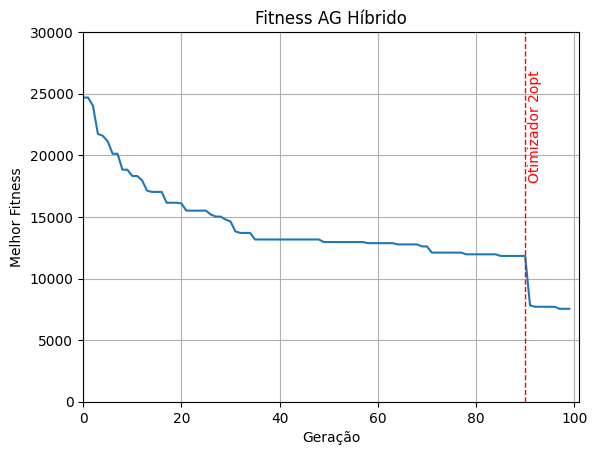

In [12]:
ROOT = os.path.abspath(os.path.join(".."))
caminhho = os.path.join(ROOT, "outputs", "graficos", f"{Juncao}.png")
linha_otmizador = geracao - (geracao*Valor_otimizador)
limite_y = Arredondar_cima(max(evo))

plt.plot(evolucao.historico["Melhor_fitness"])
plt.xlabel("Geração")
plt.ylabel("Melhor Fitness")
plt.ylim(0, limite_y)
plt.xlim(0, geracao + 1)
plt.axvline(x=linha_otmizador, color='r', linestyle='--', linewidth=1)
plt.text(linha_otmizador + 0.5, limite_y*0.6, 'Otimizador 2opt', rotation=90, color='red')
plt.title("Fitness " + Nome)
plt.grid(True)
plt.savefig(caminhho,dpi=300, bbox_inches="tight")
plt.show()

In [13]:
Imagens_para_gif(evolucao,df,tamanho_populacao,Nome)
ROOT = os.path.abspath(os.path.join(".."))
INPUT = os.path.join(ROOT, "outputs", "imagens", "*.png")
OUTPUT = os.path.join(ROOT, "outputs", "gifs", f"{Juncao}.gif")
Criar_Gif(INPUT, OUTPUT)
Melhor_rota(evolucao,df,tamanho_populacao,Juncao,Nome)

### Resultados

In [14]:
print("\n" + "="*40)
print(f"RESULTADOS - {Nome}")
print("="*40)

print(f"Assimetria:             {assimetria:.4f}")
print(f"Curtose:                {curtose:.4f}")
print(f"Desvio padrão:          {desvio_padrao:.4f}")
print(f"Tempo de execução:      {tempo_de_execucao:.2f} s")
print(f"Gerações até convergir: {Tempo_ate_convergir}")

print("-"*40)
print(f"Melhor fitness:         {min(evo):.4f}")
print(f"Melhor rota encontrada:\n{melhor_rota}")
print("-"*40)
print(f"Ótimo Global:           {(Otimo_global):.4f}")
print(f"Gap:                    {(min(evo) - Otimo_global):.4f}")

print("="*40)


RESULTADOS - AG Híbrido
Assimetria:             0.8900
Curtose:                1.5296
Desvio padrão:          3499.1006
Tempo de execução:      27.28 s
Gerações até convergir: 97
----------------------------------------
Melhor fitness:         7544.3659
Melhor rota encontrada:
[43 33 34 35 38 39 36 37 47 23  4 14  5  3 24 11 27 26 25 46 12 13 51 10
 50 32 42  9  8  7 40 18 44 31 48  0 21 30 17  2 16 20 41  6  1 29 22 19
 49 28 15 45]
----------------------------------------
Ótimo Global:           7544.3659
Gap:                    0.0000


## Clássico

In [15]:
Nome = "AG Clássico"
tam = problema.name
Juncao = Nome +" " +tam

In [16]:
populacao = Populacao(avaliacao, cromossos_totais, tamanho_populacao)
populacao.gerar_populacao()
populacao.avaliar()
selecao= Torneio(populacao)
cruzamento = UmPonto(tamanho_populacao)
mutacao = Swap(pmut)
evolucao = Evolucao_classica(populacao,selecao,
                    cruzamento,mutacao)

evolucao.nsele = round(tamanho_populacao/2)
evolucao.pcruz = 0.8

In [17]:
inicio = time.time()
for _ in range(geracao):
    ger, mini, melhor= evolucao.evoluir()
    print(f"Geração {ger:3d} | Melhor fitness: {mini:.2f} | Melhor rota: {melhor}")
fim = time.time()

Geração   1 | Melhor fitness: 26057.93 | Melhor rota: [32  9 51 26 47 23 40  7  3 35 22 31  0 21  4 50 14 10 43 11 30  1 41 39
 42 16 37 34  2 18 28 36 12 24 49 29 38 17 46 25 27  8 15 33  6 48 45  5
 13 20 19 44]
Geração   2 | Melhor fitness: 25357.90 | Melhor rota: [25  5 34 39  9 50 14 32 24  1 30 12  4 19 15 49 43  6 41 38 22 46 10  8
 37  7  3 26 28 23 48  0 17 47 36 33 40 31 16 45 13 42 51 18 44  2 21 20
 35 29 11 27]
Geração   3 | Melhor fitness: 24093.98 | Melhor rota: [32  9 51 26 47 23 40  7 45 35 22 31  0 21  4 50 14 10 43 11 30  1 41 39
 42 16 37 34  2 18 28 36 12 24 49 29 38 17 46 25 27 13 33 20  5 48  6 19
  8 44  3 15]
Geração   4 | Melhor fitness: 22653.66 | Melhor rota: [32  9 51 26 47 23 40  7  3 11 35 37 24 25 39  6  1  2 18 30 22  0 33 44
 48 38 16 50 21 34 17 41 27 14 49  8 28  5 15 45 10 12 13  4 19 43 29 20
 36 46 31 42]
Geração   5 | Melhor fitness: 22653.66 | Melhor rota: [32  9 51 26 47 23 39 43  7 16 22 24 13 46 41 30 50 37 36  1  6 25 12 45
 38  3  5 33 34 1

In [18]:
evo = evolucao.historico["Melhor_fitness"].copy()
assimetria = skew(evo)
curtose = kurtosis(evo)
desvio_padrao = np.std(evo)
melhor_rota = evolucao.melhor_solucao
tempo_de_execucao = fim - inicio
Tempo_ate_convergir = Ate_convergir(evo)
Otimo_global = fun(rota)

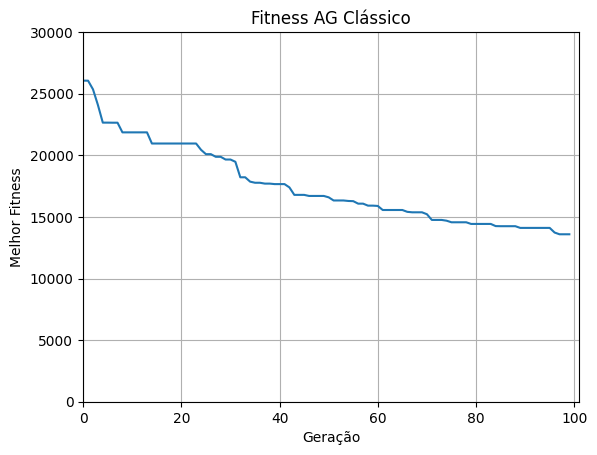

In [19]:
ROOT = os.path.abspath(os.path.join(".."))
caminhho = os.path.join(ROOT, "outputs", "graficos", f"{Juncao}.png")


plt.plot(evolucao.historico["Melhor_fitness"])
plt.xlabel("Geração")
plt.ylabel("Melhor Fitness")
plt.ylim(0, limite_y)
plt.xlim(0, geracao + 1)
plt.title("Fitness " + Nome)
plt.grid(True)
plt.savefig(caminhho,dpi=300, bbox_inches="tight")
plt.show()

In [20]:
Melhor_rota(evolucao,df,tamanho_populacao,Juncao,Nome)

### Resultados

In [21]:
print("\n" + "="*40)
print(f"RESULTADOS - {Nome}")
print("="*40)

print(f"Assimetria:             {assimetria:.4f}")
print(f"Curtose:                {curtose:.4f}")
print(f"Desvio padrão:          {desvio_padrao:.4f}")
print(f"Tempo de execução:      {tempo_de_execucao:.2f} s")
print(f"Gerações até convergir: {Tempo_ate_convergir}")

print("-"*40)
print(f"Melhor fitness:         {min(evo):.4f}")
print(f"Melhor rota encontrada:\n{melhor_rota}")
print("-"*40)
print(f"Ótimo Global:           {(Otimo_global):.4f}")
print(f"Gap:                    {(min(evo) - Otimo_global):.4f}")

print("="*40)


RESULTADOS - AG Clássico
Assimetria:             0.7574
Curtose:                -0.3976
Desvio padrão:          3179.2811
Tempo de execução:      4.99 s
Gerações até convergir: 97
----------------------------------------
Melhor fitness:         13591.2383
Melhor rota encontrada:
[26 25 51 11 27 34 35 39  4  5 23 37 47 43 36 33 14 42 32  9  8 38 45 24
 49 22  6  1 30 19 15 48  7 40 44 31  0 17 21  3 10 50 18  2 16 20 41 29
 28 46 13 12]
----------------------------------------
Ótimo Global:           7544.3659
Gap:                    6046.8724
